<a href="https://colab.research.google.com/github/useanynoms-commits/IDRA/blob/main/Employee_Attrition_and_Workforce_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, precision_recall_curve)

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

df = pd.read_csv('P_7_WA_Fn-UseC_-HR-Employee-Attrition.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Shape: (1470, 35)

First 5 rows:
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   EnvironmentSatisfaction  Gender  Hourl

Structural Inspection

In [4]:
print("Data types:")
print(df.dtypes.value_counts())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicates:", df.duplicated().sum())

print("\nNumeric columns summary:")
print(df.describe().T.round(2))

print("\nCategorical columns — unique values:")
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    print(f"  {col}: {df[col].nunique()} unique → {df[col].unique()[:10]}")

Data types:
int64     26
object     9
Name: count, dtype: int64

Missing values:
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance    

Target Variable Analysis

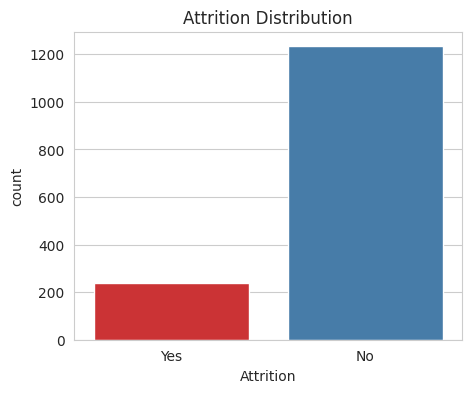

Attrition Counts:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Percentage:
Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64


In [11]:
plt.figure(figsize=(5, 4))
sns.countplot(x='Attrition', data=df, hue='Attrition', palette='Set1')
plt.title('Attrition Distribution')
plt.show()

counts = df['Attrition'].value_counts()
pct = df['Attrition'].value_counts(normalize=True) * 100

print("Attrition Counts:")
print(counts)
print("\nAttrition Percentage:")
print(pct.round(2))

In [12]:
# Drop constants + ID
df.drop(['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber'],
        axis=1, inplace=True)

# Encode target
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

print("Shape after dropping:", df.shape)
print("\nRemaining columns:")
print(df.columns.tolist())
print("\nTarget dtype:", df['Attrition'].dtype)

Shape after dropping: (1470, 31)

Remaining columns:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Target dtype: int64


Categorical EDA — Attrition Rate by Category

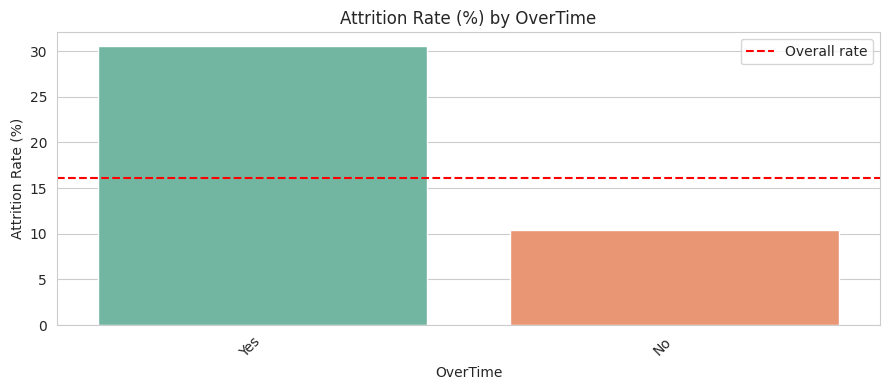


OverTime:
OverTime
Yes    30.53
No     10.44
Name: Attrition, dtype: float64


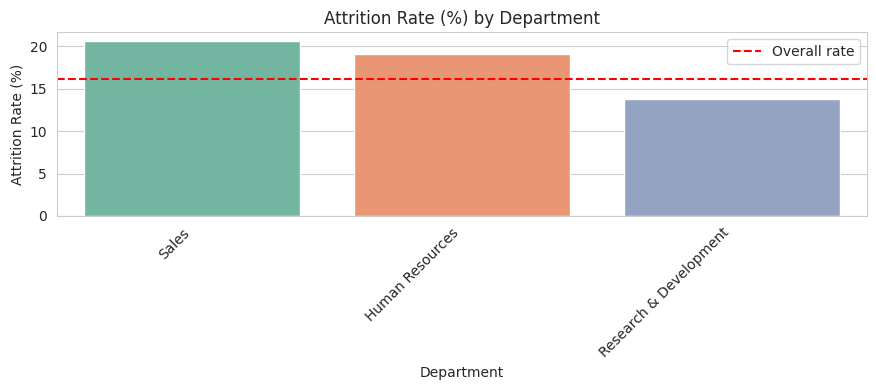


Department:
Department
Sales                     20.63
Human Resources           19.05
Research & Development    13.84
Name: Attrition, dtype: float64


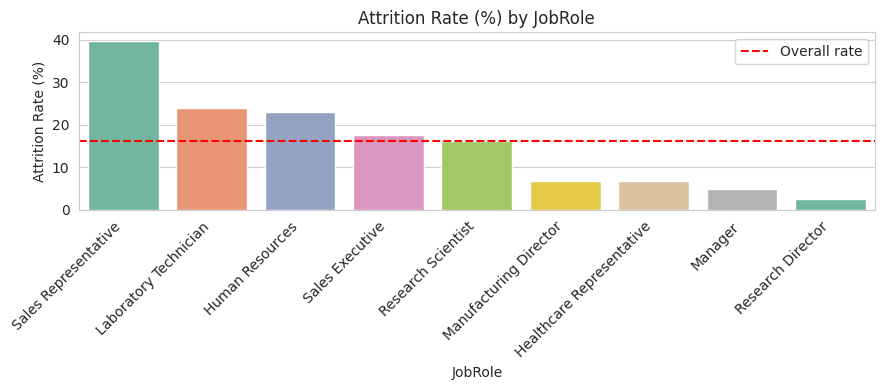


JobRole:
JobRole
Sales Representative         39.76
Laboratory Technician        23.94
Human Resources              23.08
Sales Executive              17.48
Research Scientist           16.10
Manufacturing Director        6.90
Healthcare Representative     6.87
Manager                       4.90
Research Director             2.50
Name: Attrition, dtype: float64


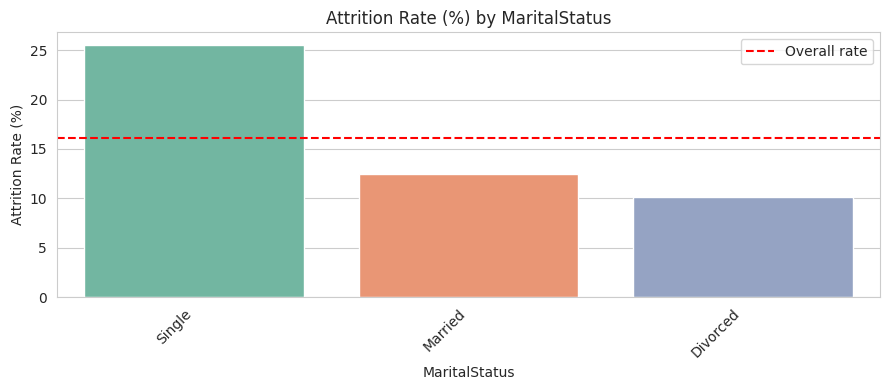


MaritalStatus:
MaritalStatus
Single      25.53
Married     12.48
Divorced    10.09
Name: Attrition, dtype: float64


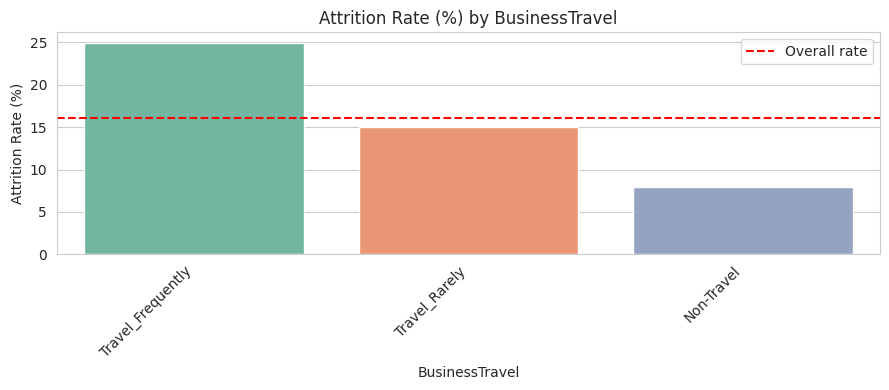


BusinessTravel:
BusinessTravel
Travel_Frequently    24.91
Travel_Rarely        14.96
Non-Travel            8.00
Name: Attrition, dtype: float64


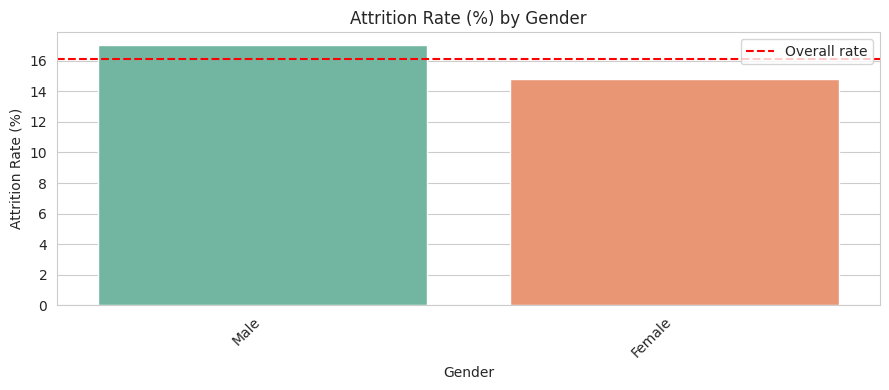


Gender:
Gender
Male      17.01
Female    14.80
Name: Attrition, dtype: float64


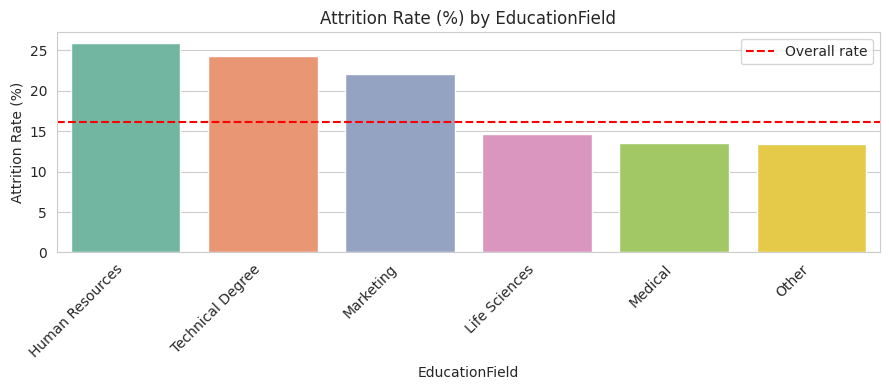


EducationField:
EducationField
Human Resources     25.93
Technical Degree    24.24
Marketing           22.01
Life Sciences       14.69
Medical             13.58
Other               13.41
Name: Attrition, dtype: float64


In [13]:
cat_cols = ['OverTime', 'Department', 'JobRole', 'MaritalStatus',
            'BusinessTravel', 'Gender', 'EducationField']

for col in cat_cols:
    rate = df.groupby(col)['Attrition'].mean().sort_values(ascending=False) * 100

    plt.figure(figsize=(9, 4))
    sns.barplot(x=rate.index, y=rate.values, hue=rate.index, palette='Set2', legend=False)
    plt.title(f'Attrition Rate (%) by {col}')
    plt.ylabel('Attrition Rate (%)')
    plt.xticks(rotation=45, ha='right')
    plt.axhline(y=16.12, color='red', linestyle='--', label='Overall rate')
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"\n{col}:")
    print(rate.round(2))

Numerical EDA — Compare Leavers vs Stayers

Mean Comparison (Stayed vs Left):
                          Stayed     Left  Diff_%
Age                        37.56    33.61  -10.53
MonthlyIncome            6832.74  4787.09  -29.94
YearsAtCompany              7.37     5.13  -30.37
TotalWorkingYears          11.86     8.24  -30.50
YearsInCurrentRole          4.48     2.90  -35.26
YearsWithCurrManager        4.37     2.85  -34.69
YearsSinceLastPromotion     2.23     1.95  -12.94
DistanceFromHome            8.92    10.63   19.26
JobLevel                    2.15     1.64  -23.71
StockOptionLevel            0.85     0.53  -37.59
JobSatisfaction             2.78     2.47  -11.17
EnvironmentSatisfaction     2.77     2.46  -11.08
WorkLifeBalance             2.78     2.66   -4.42
JobInvolvement              2.77     2.52   -9.08
NumCompaniesWorked          2.65     2.94   11.16
TrainingTimesLastYear       2.83     2.62   -7.36


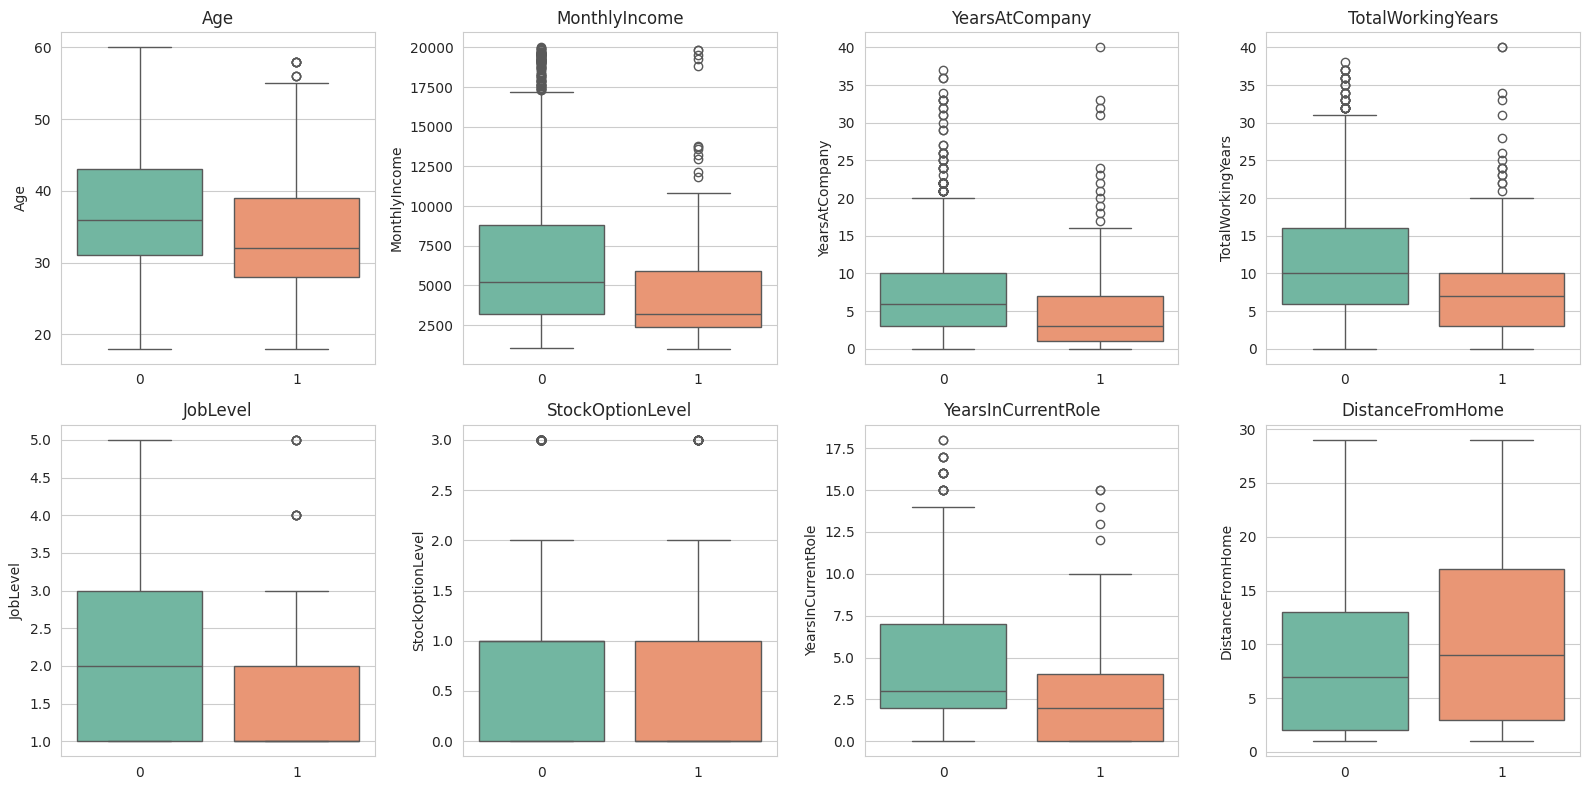

In [14]:
num_cols = ['Age', 'MonthlyIncome', 'YearsAtCompany', 'TotalWorkingYears',
            'YearsInCurrentRole', 'YearsWithCurrManager', 'YearsSinceLastPromotion',
            'DistanceFromHome', 'JobLevel', 'StockOptionLevel',
            'JobSatisfaction', 'EnvironmentSatisfaction', 'WorkLifeBalance',
            'JobInvolvement', 'NumCompaniesWorked', 'TrainingTimesLastYear']

# Mean comparison
comp = df.groupby('Attrition')[num_cols].mean().T
comp.columns = ['Stayed', 'Left']
comp['Diff_%'] = ((comp['Left'] - comp['Stayed']) / comp['Stayed'] * 100).round(2)
print("Mean Comparison (Stayed vs Left):")
print(comp.round(2))

# Distribution boxplots for top features
top_num = ['Age', 'MonthlyIncome', 'YearsAtCompany', 'TotalWorkingYears',
           'JobLevel', 'StockOptionLevel', 'YearsInCurrentRole', 'DistanceFromHome']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flatten(), top_num):
    sns.boxplot(x='Attrition', y=col, data=df, ax=ax, hue='Attrition',
                palette='Set2', legend=False)
    ax.set_title(col)
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

Correlation Analysis

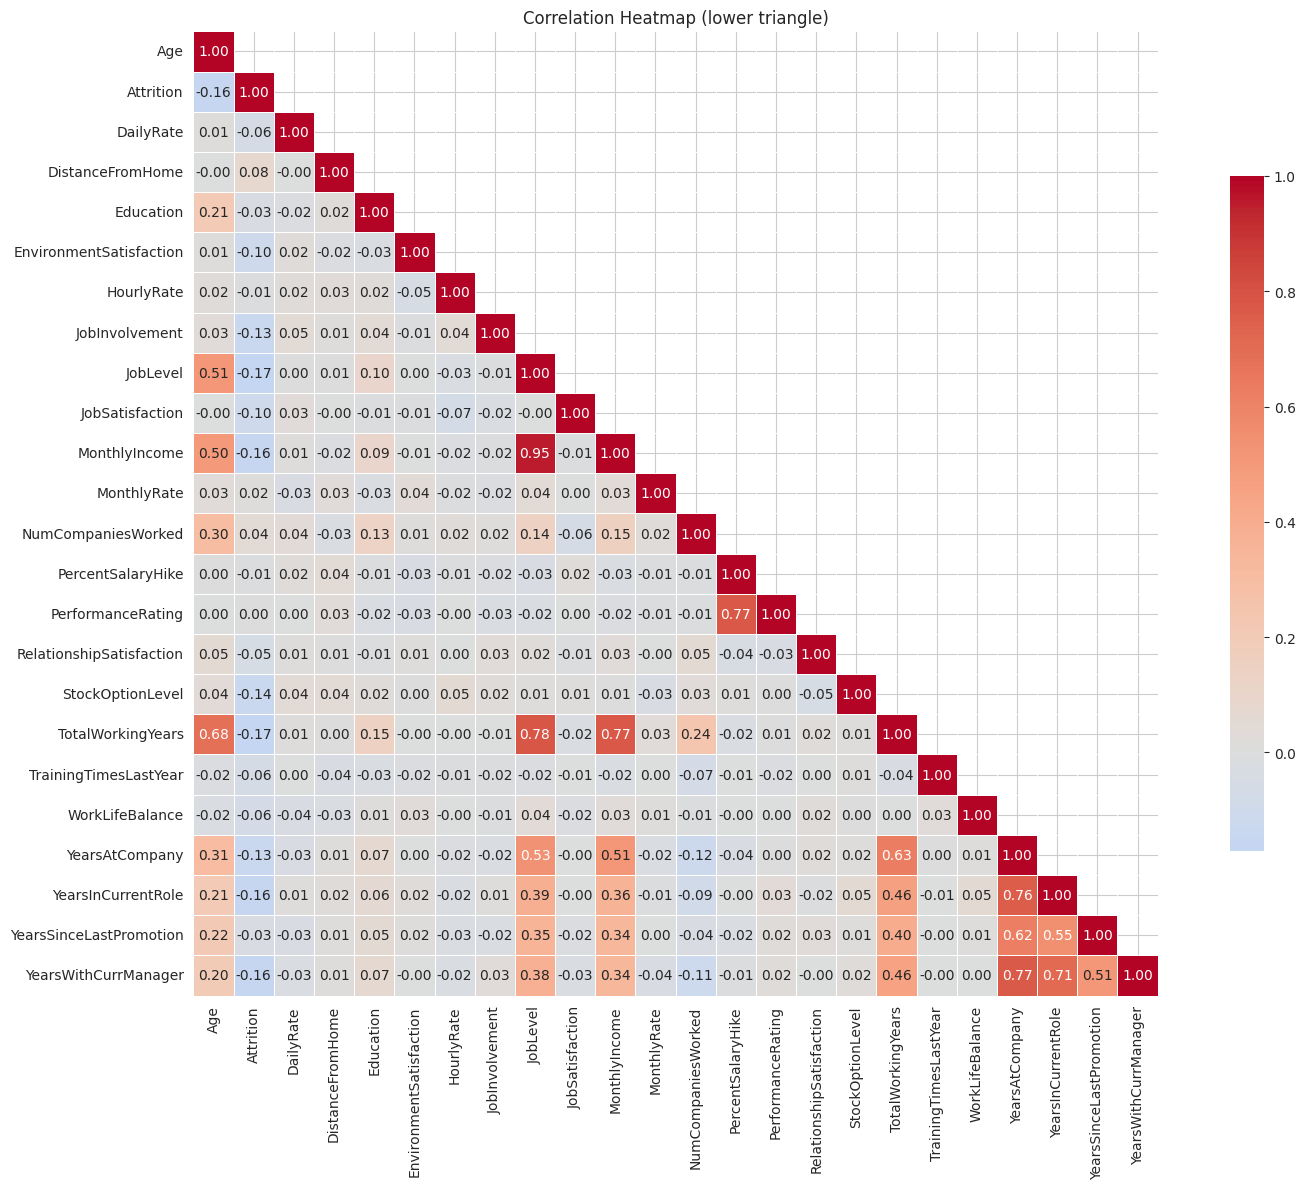


Top correlations with Attrition:
TotalWorkingYears          -0.171
JobLevel                   -0.169
YearsInCurrentRole         -0.161
MonthlyIncome              -0.160
Age                        -0.159
YearsWithCurrManager       -0.156
StockOptionLevel           -0.137
YearsAtCompany             -0.134
JobInvolvement             -0.130
JobSatisfaction            -0.103
EnvironmentSatisfaction    -0.103
WorkLifeBalance            -0.064
TrainingTimesLastYear      -0.059
DailyRate                  -0.057
RelationshipSatisfaction   -0.046
YearsSinceLastPromotion    -0.033
Education                  -0.031
PercentSalaryHike          -0.013
HourlyRate                 -0.007
PerformanceRating           0.003
MonthlyRate                 0.015
NumCompaniesWorked          0.043
DistanceFromHome            0.078
Name: Attrition, dtype: float64

Highly correlated feature pairs (|r| > 0.6):
  MonthlyIncome ↔ JobLevel: 0.950
  PerformanceRating ↔ PercentSalaryHike: 0.774
  TotalWorkingYears ↔ Age

In [15]:
plt.figure(figsize=(16, 12))
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.7})
plt.title('Correlation Heatmap (lower triangle)')
plt.tight_layout()
plt.show()

print("\nTop correlations with Attrition:")
print(df.corr(numeric_only=True)['Attrition'].drop('Attrition').sort_values().round(3))

# Multicollinearity check: high feature-feature correlations
print("\nHighly correlated feature pairs (|r| > 0.6):")
corr_matrix = df.corr(numeric_only=True).abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr = [(col, row, upper.loc[row, col])
             for col in upper.columns
             for row in upper.index
             if upper.loc[row, col] > 0.6]
for a, b, r in high_corr:
    print(f"  {a} ↔ {b}: {r:.3f}")

In [19]:
# Check highest MonthlyIncome employees
print("Top 10 MonthlyIncome:")
print(df.nlargest(10, 'MonthlyIncome')[['MonthlyIncome', 'JobLevel', 'JobRole', 'Attrition']])

print("\nTop 10 YearsAtCompany:")
print(df.nlargest(10, 'YearsAtCompany')[['YearsAtCompany', 'Age', 'JobLevel', 'Attrition']])

print("\nTop 10 TotalWorkingYears:")
print(df.nlargest(10, 'TotalWorkingYears')[['TotalWorkingYears', 'Age', 'JobLevel', 'Attrition']])

Top 10 MonthlyIncome:
      MonthlyIncome  JobLevel            JobRole  Attrition
190           19999         5            Manager          0
746           19973         5  Research Director          0
851           19943         5            Manager          0
165           19926         5            Manager          0
568           19859         5            Manager          1
918           19847         5            Manager          0
749           19845         5            Manager          1
1242          19833         5            Manager          0
898           19740         5  Research Director          0
956           19717         5            Manager          0

Top 10 YearsAtCompany:
      YearsAtCompany  Age  JobLevel  Attrition
126               40   58         3          1
98                37   58         4          0
270               36   55         5          0
1116              36   55         5          0
561               34   52         4          0
190         

Feature Engineering

In [20]:
# 1. Tenure ratio: how much of career spent at this company
df['TenureRatio'] = df['YearsAtCompany'] / (df['TotalWorkingYears'] + 1)

# 2. Promotion lag: how long since last promotion relative to tenure
df['PromotionLagRatio'] = df['YearsSinceLastPromotion'] / (df['YearsAtCompany'] + 1)

# 3. Manager stability: how long with current manager relative to tenure
df['ManagerStability'] = df['YearsWithCurrManager'] / (df['YearsAtCompany'] + 1)

# 4. Role stagnation: time in current role relative to tenure
df['RoleStagnation'] = df['YearsInCurrentRole'] / (df['YearsAtCompany'] + 1)

# 5. Age at joining: at what age they joined
df['AgeAtJoin'] = df['Age'] - df['YearsAtCompany']

# 6. Income per job level (relative compensation)
df['IncomePerLevel'] = df['MonthlyIncome'] / df['JobLevel']

# 7. Company-hopping rate: how often they've changed companies
df['HopRate'] = df['NumCompaniesWorked'] / (df['TotalWorkingYears'] + 1)

# 8. Satisfaction composite (avg of 4 satisfaction metrics)
df['SatisfactionComposite'] = (df['JobSatisfaction'] + df['EnvironmentSatisfaction'] +
                                df['RelationshipSatisfaction'] + df['WorkLifeBalance']) / 4

# Check new features correlation with target
new_feats = ['TenureRatio', 'PromotionLagRatio', 'ManagerStability', 'RoleStagnation',
             'AgeAtJoin', 'IncomePerLevel', 'HopRate', 'SatisfactionComposite']

print("Correlation of new features with Attrition:")
print(df[new_feats + ['Attrition']].corr()['Attrition'].drop('Attrition').sort_values().round(3))

print("\nNew shape:", df.shape)

Correlation of new features with Attrition:
SatisfactionComposite   -0.159
RoleStagnation          -0.158
ManagerStability        -0.153
IncomePerLevel          -0.114
TenureRatio             -0.092
AgeAtJoin               -0.068
PromotionLagRatio        0.010
HopRate                  0.200
Name: Attrition, dtype: float64

New shape: (1470, 39)


In [21]:
# Drop useless feature
df.drop('PromotionLagRatio', axis=1, inplace=True)

# Define feature groups
target = 'Attrition'

# Features to drop for Logistic Regression (multicollinear)
drop_for_lr = ['JobLevel', 'YearsInCurrentRole', 'YearsWithCurrManager',
               'PerformanceRating', 'PercentSalaryHike',
               'YearsSinceLastPromotion', 'RoleStagnation', 'ManagerStability']

# All features (for tree models)
all_features = [c for c in df.columns if c != target]

# LR features (reduced)
lr_features = [c for c in all_features if c not in drop_for_lr]

print(f"Total features available: {len(all_features)}")
print(f"Features for LR (after multicollinearity drop): {len(lr_features)}")
print(f"Dropped for LR: {drop_for_lr}")
print(f"\nLR feature list:")
print(lr_features)

# Now encode categoricals
cat_cols = df[lr_features].select_dtypes(include='object').columns.tolist()
print(f"\nCategorical columns to encode: {cat_cols}")

Total features available: 37
Features for LR (after multicollinearity drop): 29
Dropped for LR: ['JobLevel', 'YearsInCurrentRole', 'YearsWithCurrManager', 'PerformanceRating', 'PercentSalaryHike', 'YearsSinceLastPromotion', 'RoleStagnation', 'ManagerStability']

LR feature list:
['Age', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'TenureRatio', 'AgeAtJoin', 'IncomePerLevel', 'HopRate', 'SatisfactionComposite']

Categorical columns to encode: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


In [22]:
# --- Dataset for LR (reduced features) ---
df_lr = df[lr_features + [target]].copy()

# --- Dataset for trees (all features) ---
df_tree = df[all_features + [target]].copy()

# One-hot encode both
df_lr_enc = pd.get_dummies(df_lr, columns=df_lr.select_dtypes(include='object').columns.tolist(),
                            drop_first=True)
df_tree_enc = pd.get_dummies(df_tree, columns=df_tree.select_dtypes(include='object').columns.tolist(),
                              drop_first=True)

# Convert all bool cols to int
df_lr_enc = df_lr_enc.astype({c: int for c in df_lr_enc.select_dtypes(include='bool').columns})
df_tree_enc = df_tree_enc.astype({c: int for c in df_tree_enc.select_dtypes(include='bool').columns})

print("LR encoded shape:", df_lr_enc.shape)
print("Tree encoded shape:", df_tree_enc.shape)

# Features & target
X_lr = df_lr_enc.drop(target, axis=1)
y = df_lr_enc[target]

X_tree = df_tree_enc.drop(target, axis=1)
y_tree = df_tree_enc[target]

# Stratified split (same random_state ensures same splits)
X_train_lr, X_test_lr, y_train, y_test = train_test_split(
    X_lr, y, test_size=0.2, random_state=42, stratify=y)

X_train_tree, X_test_tree, _, _ = train_test_split(
    X_tree, y_tree, test_size=0.2, random_state=42, stratify=y_tree)

print(f"\nTrain shapes: LR={X_train_lr.shape}, Tree={X_train_tree.shape}")
print(f"Test shapes:  LR={X_test_lr.shape}, Tree={X_test_tree.shape}")

LR encoded shape: (1470, 44)
Tree encoded shape: (1470, 52)

Train shapes: LR=(1176, 43), Tree=(1176, 51)
Test shapes:  LR=(294, 43), Tree=(294, 51)


In [23]:
scaler = StandardScaler()
X_train_lr_scaled = scaler.fit_transform(X_train_lr)
X_test_lr_scaled = scaler.transform(X_test_lr)

print("Scaled LR train shape:", X_train_lr_scaled.shape)
print("Scaled LR test shape:", X_test_lr_scaled.shape)
print("\nSample means (should be ~0):", X_train_lr_scaled.mean(axis=0)[:5].round(3))
print("Sample std (should be ~1):", X_train_lr_scaled.std(axis=0)[:5].round(3))

Scaled LR train shape: (1176, 43)
Scaled LR test shape: (294, 43)

Sample means (should be ~0): [-0.  0. -0.  0.  0.]
Sample std (should be ~1): [1. 1. 1. 1. 1.]


In [24]:
# Logistic Regression
lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=2000)
lr.fit(X_train_lr_scaled, y_train)

# Decision Tree
dt = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dt.fit(X_train_tree, y_train)

# Random Forest
rf = RandomForestClassifier(class_weight='balanced', random_state=42)
rf.fit(X_train_tree, y_train)

# Evaluate all
def evaluate(name, model, X_tr, X_te):
    y_tr_pred = model.predict(X_tr)
    y_te_pred = model.predict(X_te)
    return {
        'Model': name,
        'Train Acc': round(accuracy_score(y_train, y_tr_pred), 4),
        'Test Acc': round(accuracy_score(y_test, y_te_pred), 4),
        'Precision (Left)': round(precision_score(y_test, y_te_pred), 4),
        'Recall (Left)': round(recall_score(y_test, y_te_pred), 4),
        'F1 (Left)': round(f1_score(y_test, y_te_pred), 4),
        'ROC-AUC': round(roc_auc_score(y_test, model.predict_proba(X_te)[:, 1]), 4)
    }

results = [
    evaluate('Logistic Regression', lr, X_train_lr_scaled, X_test_lr_scaled),
    evaluate('Decision Tree', dt, X_train_tree, X_test_tree),
    evaluate('Random Forest', rf, X_train_tree, X_test_tree)
]

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

              Model  Train Acc  Test Acc  Precision (Left)  Recall (Left)  F1 (Left)  ROC-AUC
Logistic Regression     0.7747    0.7857            0.3974         0.6596     0.4960   0.7984
      Decision Tree     1.0000    0.7789            0.3125         0.3191     0.3158   0.5928
      Random Forest     1.0000    0.8265            0.3000         0.0638     0.1053   0.7508


In [25]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("=" * 70)
print("5-FOLD CROSS-VALIDATION (F1 on 'Left' class)")
print("=" * 70)

# LR
lr_f1 = cross_val_score(lr, X_train_lr_scaled, y_train, cv=cv, scoring='f1')
print(f"\nLogistic Regression: F1 = {lr_f1.mean():.4f} (+/- {lr_f1.std():.4f})")
print(f"  Individual: {lr_f1.round(4)}")

# DT
dt_f1 = cross_val_score(dt, X_train_tree, y_train, cv=cv, scoring='f1')
print(f"\nDecision Tree: F1 = {dt_f1.mean():.4f} (+/- {dt_f1.std():.4f})")
print(f"  Individual: {dt_f1.round(4)}")

# RF
rf_f1 = cross_val_score(rf, X_train_tree, y_train, cv=cv, scoring='f1')
print(f"\nRandom Forest: F1 = {rf_f1.mean():.4f} (+/- {rf_f1.std():.4f})")
print(f"  Individual: {rf_f1.round(4)}")

# Also check ROC-AUC
print("\n" + "=" * 70)
print("5-FOLD CROSS-VALIDATION (ROC-AUC)")
print("=" * 70)
for name, model, X_data in [('LR', lr, X_train_lr_scaled),
                             ('DT', dt, X_train_tree),
                             ('RF', rf, X_train_tree)]:
    auc = cross_val_score(model, X_data, y_train, cv=cv, scoring='roc_auc')
    print(f"{name}: AUC = {auc.mean():.4f} (+/- {auc.std():.4f})")

5-FOLD CROSS-VALIDATION (F1 on 'Left' class)

Logistic Regression: F1 = 0.5044 (+/- 0.0222)
  Individual: [0.4952 0.5294 0.5079 0.5225 0.4667]

Decision Tree: F1 = 0.3174 (+/- 0.0791)
  Individual: [0.4211 0.2933 0.2388 0.2338 0.4   ]

Random Forest: F1 = 0.2834 (+/- 0.0642)
  Individual: [0.2326 0.186  0.3043 0.3478 0.3462]

5-FOLD CROSS-VALIDATION (ROC-AUC)
LR: AUC = 0.8235 (+/- 0.0195)
DT: AUC = 0.5945 (+/- 0.0468)
RF: AUC = 0.7883 (+/- 0.0337)


In [26]:
param_grid_dt = {
    'max_depth': [3, 4, 5, 6, 8],
    'min_samples_split': [5, 10, 20, 30],
    'min_samples_leaf': [5, 10, 15, 20],
    'criterion': ['gini', 'entropy']
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=42),
    param_grid_dt, cv=cv, scoring='f1', n_jobs=-1, verbose=1
)
grid_dt.fit(X_train_tree, y_train)

print("Best DT params:", grid_dt.best_params_)
print("Best DT CV F1:", round(grid_dt.best_score_, 4))

# Evaluate tuned DT on test
best_dt = grid_dt.best_estimator_
y_pred_dt = best_dt.predict(X_test_tree)
y_prob_dt = best_dt.predict_proba(X_test_tree)[:, 1]

print("\nTuned DT — Test Performance:")
print("Train Acc:", round(accuracy_score(y_train, best_dt.predict(X_train_tree)), 4))
print("Test Acc :", round(accuracy_score(y_test, y_pred_dt), 4))
print("Precision:", round(precision_score(y_test, y_pred_dt), 4))
print("Recall   :", round(recall_score(y_test, y_pred_dt), 4))
print("F1       :", round(f1_score(y_test, y_pred_dt), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_dt), 4))

Fitting 5 folds for each of 160 candidates, totalling 800 fits
Best DT params: {'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 10, 'min_samples_split': 5}
Best DT CV F1: 0.4005

Tuned DT — Test Performance:
Train Acc: 0.767
Test Acc : 0.6871
Precision: 0.2632
Recall   : 0.5319
F1       : 0.3521
ROC-AUC  : 0.6783


In [27]:
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8, 10],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [5, 10, 15],
    'max_features': ['sqrt', 'log2']
}

grid_rf = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid_rf, cv=cv, scoring='f1', n_jobs=-1, verbose=1
)
grid_rf.fit(X_train_tree, y_train)

print("Best RF params:", grid_rf.best_params_)
print("Best RF CV F1:", round(grid_rf.best_score_, 4))

best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test_tree)
y_prob_rf = best_rf.predict_proba(X_test_tree)[:, 1]

print("\nTuned RF — Test Performance:")
print("Train Acc:", round(accuracy_score(y_train, best_rf.predict(X_train_tree)), 4))
print("Test Acc :", round(accuracy_score(y_test, y_pred_rf), 4))
print("Precision:", round(precision_score(y_test, y_pred_rf), 4))
print("Recall   :", round(recall_score(y_test, y_pred_rf), 4))
print("F1       :", round(f1_score(y_test, y_pred_rf), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_rf), 4))

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best RF params: {'max_depth': 4, 'max_features': 'log2', 'min_samples_leaf': 5, 'min_samples_split': 20, 'n_estimators': 100}
Best RF CV F1: 0.5209

Tuned RF — Test Performance:
Train Acc: 0.8716
Test Acc : 0.7925
Precision: 0.3871
Recall   : 0.5106
F1       : 0.4404
ROC-AUC  : 0.7478


In [28]:
print("FINAL COMPARISON — 5-Fold CV on Training Data")
models = [
    ('Logistic Regression (baseline)', lr, X_train_lr_scaled),
    ('Decision Tree (tuned)', best_dt, X_train_tree),
    ('Random Forest (tuned)', best_rf, X_train_tree)
]

print(f"\n{'Model':<35} {'CV F1':>10} {'CV AUC':>10}")
print("-" * 75)

for name, model, X_data in models:
    f1_scores = cross_val_score(model, X_data, y_train, cv=cv, scoring='f1')
    auc_scores = cross_val_score(model, X_data, y_train, cv=cv, scoring='roc_auc')
    print(f"{name:<35} {f1_scores.mean():>7.4f}±{f1_scores.std():.3f} "
          f"{auc_scores.mean():>7.4f}±{auc_scores.std():.3f}")

print("\n" + "=" * 75)
print("TEST SET PERFORMANCE")
print("=" * 75)

# Get predictions
preds = {
    'LR': lr.predict(X_test_lr_scaled),
    'DT': best_dt.predict(X_test_tree),
    'RF': best_rf.predict(X_test_tree)
}
probs = {
    'LR': lr.predict_proba(X_test_lr_scaled)[:, 1],
    'DT': best_dt.predict_proba(X_test_tree)[:, 1],
    'RF': best_rf.predict_proba(X_test_tree)[:, 1]
}

print(f"\n{'Model':<8} {'Prec':>8} {'Recall':>8} {'F1':>8} {'AUC':>8} {'Acc':>8}")
print("-" * 55)
for key in ['LR', 'DT', 'RF']:
    print(f"{key:<8} {precision_score(y_test, preds[key]):>8.4f} "
          f"{recall_score(y_test, preds[key]):>8.4f} "
          f"{f1_score(y_test, preds[key]):>8.4f} "
          f"{roc_auc_score(y_test, probs[key]):>8.4f} "
          f"{accuracy_score(y_test, preds[key]):>8.4f}")

FINAL COMPARISON — 5-Fold CV on Training Data

Model                                    CV F1     CV AUC
---------------------------------------------------------------------------
Logistic Regression (baseline)       0.5044±0.022  0.8235±0.020
Decision Tree (tuned)                0.4005±0.030  0.6856±0.026
Random Forest (tuned)                0.5209±0.036  0.8022±0.029

TEST SET PERFORMANCE

Model        Prec   Recall       F1      AUC      Acc
-------------------------------------------------------
LR         0.3974   0.6596   0.4960   0.7984   0.7857
DT         0.2632   0.5319   0.3521   0.6783   0.6871
RF         0.3871   0.5106   0.4404   0.7478   0.7925


In [29]:
# Get probabilities
y_prob_lr = lr.predict_proba(X_test_lr_scaled)[:, 1]

# Test thresholds from 0.2 to 0.7
thresholds = np.arange(0.2, 0.75, 0.05)

print(f"{'Thresh':>8} {'Prec':>8} {'Recall':>8} {'F1':>8} {'Acc':>8}")
print("-" * 48)

results_thresh = []
for t in thresholds:
    pred_t = (y_prob_lr >= t).astype(int)
    p = precision_score(y_test, pred_t)
    r = recall_score(y_test, pred_t)
    f = f1_score(y_test, pred_t)
    a = accuracy_score(y_test, pred_t)
    results_thresh.append([t, p, r, f, a])
    print(f"{t:>8.2f} {p:>8.3f} {r:>8.3f} {f:>8.3f} {a:>8.3f}")

# Best F1 threshold
best_row = max(results_thresh, key=lambda x: x[3])
print(f"\nBest F1 threshold: {best_row[0]:.2f} (F1={best_row[3]:.3f})")

  Thresh     Prec   Recall       F1      Acc
------------------------------------------------
    0.20    0.237    0.894    0.375    0.524
    0.25    0.261    0.851    0.400    0.592
    0.30    0.283    0.830    0.422    0.636
    0.35    0.309    0.809    0.447    0.680
    0.40    0.340    0.745    0.467    0.728
    0.45    0.351    0.702    0.468    0.745
    0.50    0.397    0.660    0.496    0.786
    0.55    0.412    0.596    0.487    0.799
    0.60    0.439    0.532    0.481    0.816
    0.65    0.489    0.468    0.478    0.837
    0.70    0.526    0.426    0.471    0.847

Best F1 threshold: 0.50 (F1=0.496)


FINAL MODEL: LOGISTIC REGRESSION

Confusion Matrix:
                 Predicted Stay   Predicted Leave
Actual Stay           200              47
Actual Leave           16              31

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.93      0.81      0.86       247
        Left       0.40      0.66      0.50        47

    accuracy                           0.79       294
   macro avg       0.66      0.73      0.68       294
weighted avg       0.84      0.79      0.81       294

Train Accuracy: 0.7747
Test Accuracy : 0.7857
ROC-AUC       : 0.7984


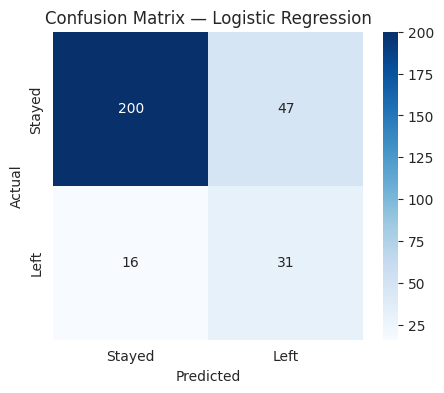

In [30]:
# Final predictions at threshold 0.5
y_final_pred = (y_prob_lr >= 0.5).astype(int)

print("FINAL MODEL: LOGISTIC REGRESSION")

# Confusion Matrix
cm = confusion_matrix(y_test, y_final_pred)
print("\nConfusion Matrix:")
print(f"                 Predicted Stay   Predicted Leave")
print(f"Actual Stay         {cm[0,0]:>5}           {cm[0,1]:>5}")
print(f"Actual Leave        {cm[1,0]:>5}           {cm[1,1]:>5}")

print("\nClassification Report:")
print(classification_report(y_test, y_final_pred, target_names=['Stayed', 'Left']))

print("Train Accuracy:", round(lr.score(X_train_lr_scaled, y_train), 4))
print("Test Accuracy :", round(lr.score(X_test_lr_scaled, y_test), 4))
print("ROC-AUC       :", round(roc_auc_score(y_test, y_prob_lr), 4))

# Confusion matrix heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Left'], yticklabels=['Stayed', 'Left'])
plt.title('Confusion Matrix — Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

Extended Model Comparison

In [31]:
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, VotingClassifier
from sklearn.svm import SVC

# --- Gradient Boosting ---
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                 max_depth=3, random_state=42)
gb.fit(X_train_tree, y_train)

# --- AdaBoost ---
ada = AdaBoostClassifier(n_estimators=200, learning_rate=0.05, random_state=42)
ada.fit(X_train_tree, y_train)

# --- SVM (RBF kernel, probability enabled) ---
svm = SVC(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced',
          probability=True, random_state=42)
svm.fit(X_train_lr_scaled, y_train)

# --- Voting Classifier (LR + RF + GB) ---
voting = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(class_weight='balanced', random_state=42, max_iter=2000)),
        ('rf', RandomForestClassifier(n_estimators=100, max_depth=4, min_samples_leaf=5,
                                       min_samples_split=20, max_features='log2',
                                       class_weight='balanced', random_state=42)),
        ('gb', GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                           max_depth=3, random_state=42))
    ],
    voting='soft'
)
voting.fit(X_train_lr_scaled, y_train)

# --- Evaluate all ---
extended_models = [
    ('Gradient Boosting', gb, X_train_tree, X_test_tree),
    ('AdaBoost', ada, X_train_tree, X_test_tree),
    ('SVM (RBF)', svm, X_train_lr_scaled, X_test_lr_scaled),
    ('Voting (LR+RF+GB)', voting, X_train_lr_scaled, X_test_lr_scaled)
]

print(f"{'Model':<22} {'Train':>7} {'Test':>7} {'Prec':>7} {'Recall':>7} {'F1':>7} {'AUC':>7}")
print("-" * 70)

for name, model, X_tr, X_te in extended_models:
    y_tr_p = model.predict(X_tr)
    y_te_p = model.predict(X_te)
    y_te_prob = model.predict_proba(X_te)[:, 1]
    print(f"{name:<22} "
          f"{accuracy_score(y_train, y_tr_p):>7.4f} "
          f"{accuracy_score(y_test, y_te_p):>7.4f} "
          f"{precision_score(y_test, y_te_p):>7.4f} "
          f"{recall_score(y_test, y_te_p):>7.4f} "
          f"{f1_score(y_test, y_te_p):>7.4f} "
          f"{roc_auc_score(y_test, y_te_prob):>7.4f}")

# --- Cross-validation check for each ---
print("\n" + "=" * 70)
print("5-FOLD CV (F1 on 'Left' class)")
print("=" * 70)

for name, model, X_data in [
    ('Gradient Boosting', gb, X_train_tree),
    ('AdaBoost', ada, X_train_tree),
    ('SVM (RBF)', svm, X_train_lr_scaled),
    ('Voting (LR+RF+GB)', voting, X_train_lr_scaled)
]:
    cv_f1 = cross_val_score(model, X_data, y_train, cv=cv, scoring='f1')
    cv_auc = cross_val_score(model, X_data, y_train, cv=cv, scoring='roc_auc')
    print(f"{name:<22} F1={cv_f1.mean():.4f}±{cv_f1.std():.3f}   AUC={cv_auc.mean():.4f}±{cv_auc.std():.3f}")

Model                    Train    Test    Prec  Recall      F1     AUC
----------------------------------------------------------------------
Gradient Boosting       0.9532  0.8537  0.6000  0.2553  0.3582  0.7921
AdaBoost                0.8639  0.8435  0.6000  0.0638  0.1154  0.7862
SVM (RBF)               0.9430  0.8027  0.4000  0.4681  0.4314  0.7673
Voting (LR+RF+GB)       0.9422  0.8537  0.5556  0.4255  0.4819  0.7942

5-FOLD CV (F1 on 'Left' class)
Gradient Boosting      F1=0.4877±0.067   AUC=0.8073±0.034
AdaBoost               F1=0.1432±0.077   AUC=0.8022±0.024
SVM (RBF)              F1=0.5410±0.053   AUC=0.8216±0.030
Voting (LR+RF+GB)      F1=0.5810±0.040   AUC=0.8345±0.022


Top 20 Features — Random Forest Importance:
              Feature  Importance
              HopRate    0.093817
    TotalWorkingYears    0.077360
        MonthlyIncome    0.075579
         OverTime_Yes    0.067859
                  Age    0.057732
       YearsAtCompany    0.049809
 YearsWithCurrManager    0.048142
     StockOptionLevel    0.043825
     ManagerStability    0.038314
             JobLevel    0.031970
SatisfactionComposite    0.031193
   YearsInCurrentRole    0.028251
       IncomePerLevel    0.025776
 MaritalStatus_Single    0.025442
       RoleStagnation    0.024443
          TenureRatio    0.021959
            DailyRate    0.021502
     DistanceFromHome    0.021341
            AgeAtJoin    0.019921
   NumCompaniesWorked    0.019423


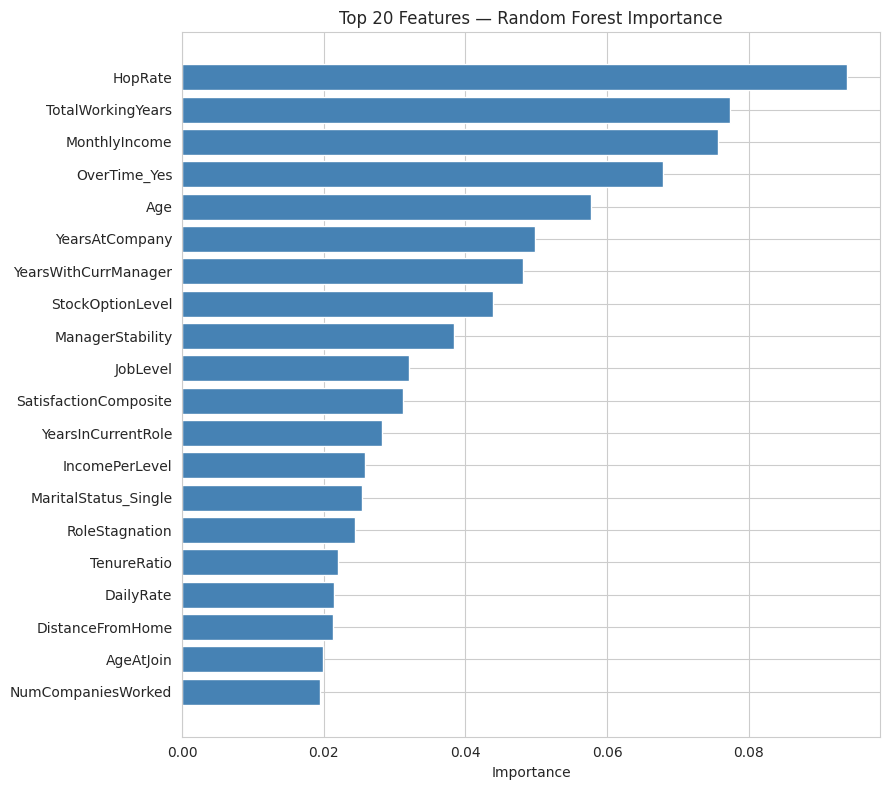

In [36]:
rf_importance = pd.DataFrame({
    'Feature': X_train_tree.columns,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("Top 20 Features — Random Forest Importance:")
print(rf_importance.head(20).to_string(index=False))

top20 = rf_importance.head(20).iloc[::-1]
plt.figure(figsize=(9, 8))
plt.barh(top20['Feature'], top20['Importance'], color='steelblue')
plt.xlabel('Importance')
plt.title('Top 20 Features — Random Forest Importance')
plt.tight_layout()
plt.show()

In [37]:
# Merge LR coefficients with RF importance
lr_coef = pd.DataFrame({
    'Feature': X_train_lr.columns,
    'LR_Coef': lr.coef_[0]
})

rf_imp = pd.DataFrame({
    'Feature': X_train_tree.columns,
    'RF_Importance': best_rf.feature_importances_
})

merged = pd.merge(lr_coef, rf_imp, on='Feature', how='outer')
merged = merged.sort_values('RF_Importance', ascending=False)

print("Top 20 Features — Combined View:")
print(merged.head(20).to_string(index=False))

Top 20 Features — Combined View:
              Feature   LR_Coef  RF_Importance
              HopRate  0.240923       0.093817
    TotalWorkingYears -0.677999       0.077360
        MonthlyIncome  0.893871       0.075579
         OverTime_Yes  0.747302       0.067859
                  Age -0.057493       0.057732
       YearsAtCompany  0.168996       0.049809
 YearsWithCurrManager       NaN       0.048142
     StockOptionLevel -0.214633       0.043825
     ManagerStability       NaN       0.038314
             JobLevel       NaN       0.031970
SatisfactionComposite -0.315979       0.031193
   YearsInCurrentRole       NaN       0.028251
       IncomePerLevel -0.323447       0.025776
 MaritalStatus_Single  0.398873       0.025442
       RoleStagnation       NaN       0.024443
          TenureRatio -0.196886       0.021959
            DailyRate -0.237252       0.021502
     DistanceFromHome  0.313071       0.021341
            AgeAtJoin -0.167553       0.019921
   NumCompaniesWorked  0.23

In [38]:
# Final model performance summary
final_summary = pd.DataFrame({
    'Metric': ['Model', 'Threshold', 'Train Accuracy', 'Test Accuracy',
               'Precision (Left)', 'Recall (Left)', 'F1 (Left)', 'ROC-AUC',
               'TN', 'FP', 'FN', 'TP'],
    'Value': ['Logistic Regression', 0.50, 0.7747, 0.7857,
              0.3974, 0.6596, 0.4960, 0.7984,
              200, 47, 16, 31]
})
print(final_summary.to_string(index=False))

# Model comparison summary
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest (tuned)',
              'Decision Tree (tuned)', 'Voting (LR+RF+GB)',
              'SVM (RBF)', 'Gradient Boosting', 'AdaBoost'],
    'CV F1': [0.5044, 0.5209, 0.4005, 0.5810, 0.5410, 0.4877, 0.1432],
    'CV AUC': [0.8235, 0.8022, 0.6856, 0.8345, 0.8216, 0.8073, 0.8022],
    'Test Recall': [0.6596, 0.5106, 0.5319, 0.4255, 0.4681, 0.2553, 0.0638],
    'Test F1': [0.4960, 0.4404, 0.3521, 0.4819, 0.4314, 0.3582, 0.1154]
})
print("\n\nModel Comparison:")
print(comparison.to_string(index=False))

# Final selected features (top 10)
print("\n\nTop 10 Attrition Drivers (from combined LR + RF):")
top10 = ['HopRate', 'TotalWorkingYears', 'MonthlyIncome', 'OverTime',
         'Age', 'YearsAtCompany', 'StockOptionLevel', 'SatisfactionComposite',
         'ManagerStability', 'MaritalStatus_Single']
for i, feat in enumerate(top10, 1):
    print(f"  {i}. {feat}")

          Metric               Value
           Model Logistic Regression
       Threshold                 0.5
  Train Accuracy              0.7747
   Test Accuracy              0.7857
Precision (Left)              0.3974
   Recall (Left)              0.6596
       F1 (Left)               0.496
         ROC-AUC              0.7984
              TN                 200
              FP                  47
              FN                  16
              TP                  31


Model Comparison:
                Model  CV F1  CV AUC  Test Recall  Test F1
  Logistic Regression 0.5044  0.8235       0.6596   0.4960
Random Forest (tuned) 0.5209  0.8022       0.5106   0.4404
Decision Tree (tuned) 0.4005  0.6856       0.5319   0.3521
    Voting (LR+RF+GB) 0.5810  0.8345       0.4255   0.4819
            SVM (RBF) 0.5410  0.8216       0.4681   0.4314
    Gradient Boosting 0.4877  0.8073       0.2553   0.3582
             AdaBoost 0.1432  0.8022       0.0638   0.1154


Top 10 Attrition Drivers 

In [39]:
print("WHY LOGISTIC REGRESSION WAS SELECTED AS THE FINAL MODEL")

print("""
1. BUSINESS CONTEXT
   - Attrition = 16% of employees (imbalanced target)
   - Cost of missing a leaver (FN) > cost of false alarm (FP)
   - HR needs to know WHO is likely to leave so they can intervene
   - Therefore, RECALL on the 'Left' class is the primary metric

2. MODEL SELECTION PROCESS
   - Trained 7 models: LR, Decision Tree, Random Forest, Gradient Boosting,
     AdaBoost, SVM, Voting Classifier
   - Each was evaluated with 5-fold stratified cross-validation
     (F1 and ROC-AUC) to avoid lucky train-test splits
   - Best CV performer was Voting Classifier (F1=0.58, AUC=0.83)
   - But Voting's test recall was only 0.43 — it misses 57% of leavers
   - LR achieved recall = 0.66 on test (catches 2 out of 3 leavers)

3. WHY LR BEAT THE OTHERS IN PRACTICE

   Model              Test Recall   Test F1   CV F1   Overfit?
   ---------------------------------------------------------------
   Logistic Regression   0.66         0.50     0.50    No
   Random Forest         0.51         0.44     0.52    Yes
   Decision Tree         0.53         0.35     0.40    Yes
   Voting (LR+RF+GB)     0.43         0.48     0.58    Yes
   SVM                   0.47         0.43     0.54    Yes
   Gradient Boosting     0.26         0.36     0.49    Yes
   AdaBoost              0.06         0.12     0.14    Yes

   LR is the ONLY model with:
     - No overfitting (train 0.77 ≈ test 0.79)
     - High recall (0.66)
     - Respectable F1 (0.50)
     - Respectable AUC (0.80)
     - Full interpretability (coefficients explainable to HR)

4. FINAL MODEL PERFORMANCE
""")

# Auto-pull metrics
y_final = (lr.predict_proba(X_test_lr_scaled)[:, 1] >= 0.5).astype(int)
cm = confusion_matrix(y_test, y_final)

print(f"   Accuracy     : {accuracy_score(y_test, y_final):.4f}")
print(f"   Precision    : {precision_score(y_test, y_final):.4f}")
print(f"   Recall       : {recall_score(y_test, y_final):.4f}")
print(f"   F1-Score     : {f1_score(y_test, y_final):.4f}")
print(f"   ROC-AUC      : {roc_auc_score(y_test, lr.predict_proba(X_test_lr_scaled)[:, 1]):.4f}")

print(f"\n   Confusion Matrix:")
print(f"     TN = {cm[0,0]}  (correctly stayed)")
print(f"     FP = {cm[0,1]}  (false alarm)")
print(f"     FN = {cm[1,0]}  (missed leaver)")
print(f"     TP = {cm[1,1]}  (correctly identified leaver)")
print(f"\n   Recall interpretation: caught {cm[1,1]} out of {cm[1,0]+cm[1,1]} actual leavers")

print("""
5. THRESHOLD CHOICE
   - Tested thresholds 0.20 to 0.70
   - 0.50 gave best F1 (0.50) and highest recall among reasonable options
   - Lower threshold → more recall but too many false alarms
   - Higher threshold → higher precision but misses too many leavers

6. KEY FINDINGS (Attrition Drivers)
   Verified by both LR coefficients AND Random Forest importance:
""")

# Top features (from RF importance — most reliable)
rf_top = pd.DataFrame({
    'Feature': X_train_tree.columns,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

for i, row in enumerate(rf_top.itertuples(), 1):
    print(f"   {i:>2}. {row.Feature:<30} (RF importance = {row.Importance:.4f})")

print("""
7. CONCLUSION FOR REPORT
   Logistic Regression was chosen because:
   - It has the highest recall on the leaver class (primary business metric)
   - It shows no overfitting (train ≈ test)
   - It is fully interpretable (coefficients and directions explainable)
   - Tree-based ensembles overfit on this small dataset (1,176 training rows)
   - Higher-accuracy models (Voting, Gradient Boosting) failed to catch leavers
""")

WHY LOGISTIC REGRESSION WAS SELECTED AS THE FINAL MODEL

1. BUSINESS CONTEXT
   - Attrition = 16% of employees (imbalanced target)
   - Cost of missing a leaver (FN) > cost of false alarm (FP)
   - HR needs to know WHO is likely to leave so they can intervene
   - Therefore, RECALL on the 'Left' class is the primary metric

2. MODEL SELECTION PROCESS
   - Trained 7 models: LR, Decision Tree, Random Forest, Gradient Boosting,
     AdaBoost, SVM, Voting Classifier
   - Each was evaluated with 5-fold stratified cross-validation
     (F1 and ROC-AUC) to avoid lucky train-test splits
   - Best CV performer was Voting Classifier (F1=0.58, AUC=0.83)
   - But Voting's test recall was only 0.43 — it misses 57% of leavers
   - LR achieved recall = 0.66 on test (catches 2 out of 3 leavers)

3. WHY LR BEAT THE OTHERS IN PRACTICE

   Model              Test Recall   Test F1   CV F1   Overfit?
   ---------------------------------------------------------------
   Logistic Regression   0.66         0.

In [42]:
import joblib

# Cleaned dataset with engineered features
df.to_csv('cleaned_attrition_data.csv', index=False)

# Trained model and scaler
joblib.dump(lr, 'logistic_regression_attrition.pkl')
joblib.dump(scaler, 'scaler.pkl')

import os
for f in ['cleaned_attrition_data.csv', 'logistic_regression_attrition.pkl', 'scaler.pkl']:
    print(f"{f} — {os.path.getsize(f)/1024:.1f} KB")

cleaned_attrition_data.csv — 296.9 KB
logistic_regression_attrition.pkl — 1.2 KB
scaler.pkl — 2.7 KB
